<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q2. Dataset Selection & Initial Exploration
Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [47]:
from google.colab import files

uploaded = files.upload()

Saving house_price_regression_dataset.csv to house_price_regression_dataset (3).csv


In [ ]:
df = pd.read_csv("house_price_regression_dataset.csv")

df.head(10)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
5,3944,5,3,1990,2.475930,2,8,8.797970e+05
6,3671,1,2,2012,4.911960,0,1,8.144279e+05
7,3419,1,1,1972,2.805281,1,1,7.034131e+05
8,630,3,3,1997,1.014286,1,8,1.738750e+05
9,2185,4,2,1981,3.941604,2,5,5.041765e+05


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 8)


In [ ]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


Q3. Missing & Duplicate Values Analysis
Missing Values

In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df

,Missing Values,Percentage
Square_Footage,0,0.0
Num_Bedrooms,0,0.0
Num_Bathrooms,0,0.0
Year_Built,0,0.0
Lot_Size,0,0.0
Garage_Size,0,0.0
Neighborhood_Quality,0,0.0
House_Price,0,0.0


In [ ]:
for column in df.columns:

    if df[column].dtype == "object":
        df[column].fillna(df[column].mode()[0], inplace=True)

    else:
        df[column].fillna(df[column].median(), inplace=True)

/tmp/ipykernel_7933/3741682874.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(1000, 8)


In [ ]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


Q4. Statistical Summary
 Generate Statistical Summary

In [ ]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
target = "House_Price"

print("Minimum House Price :", df[target].min())
print("Maximum House Price :", df[target].max())
print("Mean House Price    :", df[target].mean())
print("Median House Price  :", df[target].median())

Minimum House Price : 111626.85342361582
Maximum House Price : 1108236.8362913695
Mean House Price    : 618861.0186467685
Median House Price  : 628267.2911288175


Q5. Histogram Analysis of Numeric Features
Find Numeric Columns

In [ ]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_columns)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


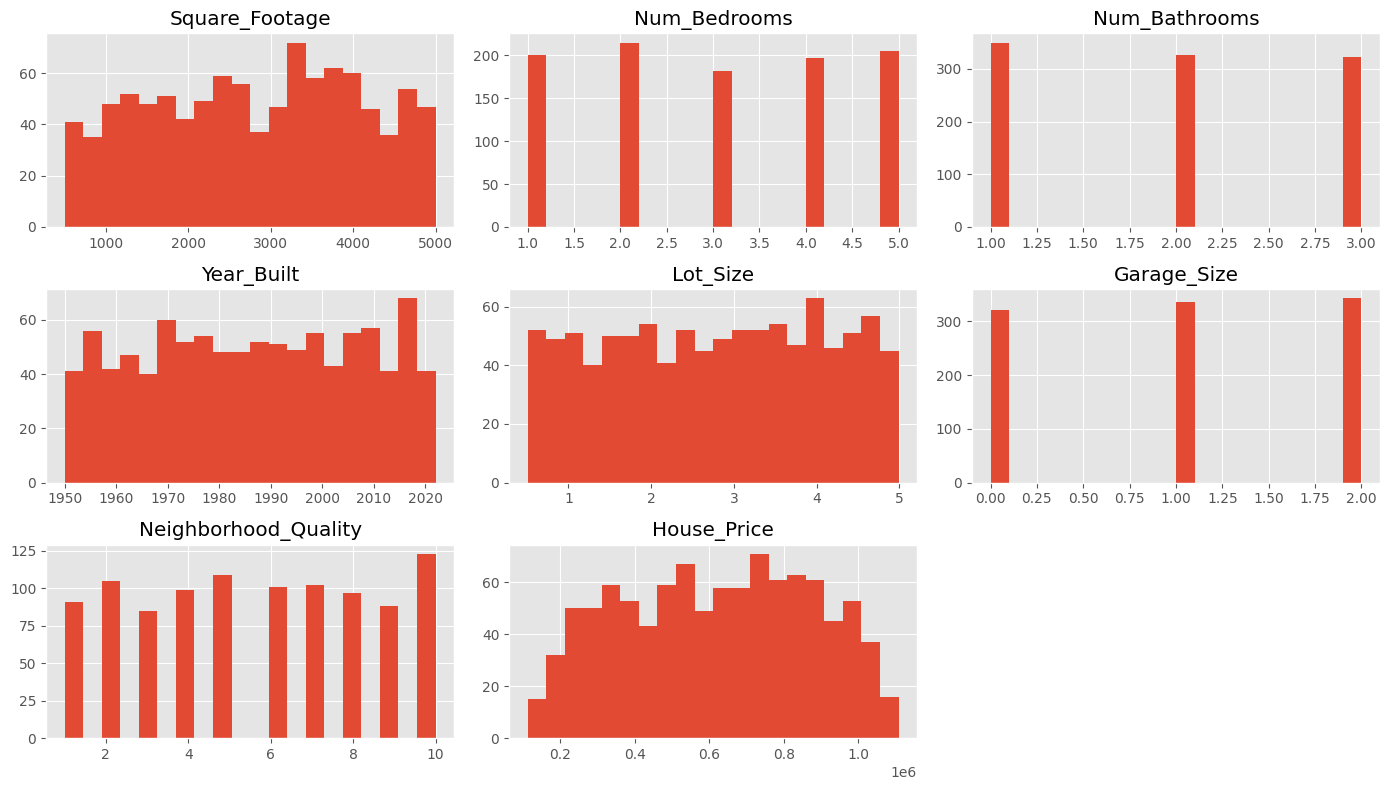

In [44]:
df[numeric_columns].hist(figsize=(14, 8), bins=20)

plt.tight_layout()
plt.show()

Q6. Count Plots of Categorical Features
Find Categorical Columns

In [ ]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index([], dtype='object')


In [50]:
categorical_columns = df.select_dtypes(include=["object"]).columns

if len(categorical_columns) == 0:
    print("No categorical columns are present in this dataset.")
else:
    for column in categorical_columns:
        plt.figure(figsize=(8,5))
        sns.countplot(x=df[column])
        plt.title(f"Count Plot of {column}")
        plt.xticks(rotation=45)
        plt.show()

No categorical columns are present in this dataset.


Q7. Correlation Heatmap
Correlation Matrix

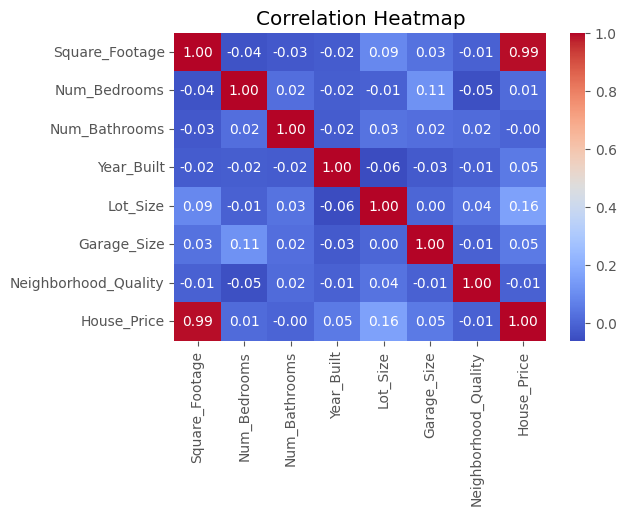

In [24]:
plt.figure(figsize=(6,4))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target = "House_Price"

correlation_target = correlation[target].sort_values(ascending=False)

print(correlation_target)

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


Q8. Feature Identification
Independent and Dependent Features

In [28]:
target = "House_Price"

X = df.drop(target, axis=1)

y = df[target]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality'],
      dtype='object')

Dependent Feature (y):
House_Price


Q9. Encoding Categorical Variables
Show Categorical Columns

In [37]:


categorical_columns = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

if len(categorical_columns) == 0:
    print("\nNo categorical columns are present in the dataset.")
    print("Therefore, One-Hot Encoding is not required.")
    X_encoded = X.copy()
else:
    print("\nBefore Encoding:")
    print(X[categorical_columns].head())

    X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

    print("\nAfter Encoding:")
    print(X_encoded.head())

Categorical Columns:
Index([], dtype='object')

No categorical columns are present in the dataset.
Therefore, One-Hot Encoding is not required.


Q10. Feature Scaling
Import StandardScaler

In [52]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

In [41]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

X_scaled.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,-1.159803,-0.693836,-1.186699,-0.269122,-1.679278,-1.254658,-0.213126
1,1.160724,0.007008,1.252559,1.428045,1.522390,-0.027008,0.133420
2,0.618843,-1.394681,0.032930,1.428045,0.660422,-1.254658,1.173060
3,-1.473776,-1.394681,0.032930,-0.463084,-0.036555,-0.027008,0.826514
4,1.681887,-0.693836,-1.186699,0.312764,1.480809,-1.254658,0.826514
